1. 환경 설정 및 라이브러리 임포트

In [2]:
import datasets
from datasets import load_dataset, DatasetDict
from transformers import pipeline
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# GPU 사용 가능 여부 확인 및 설정
device = 0 if torch.cuda.is_available() else -1
print(f"사용 가능한 디바이스: {'GPU' if device == 0 else 'CPU'}")
# print(f"torch 버전: {torch.__version__}, datasets 버전: {datasets.__version__}")

사용 가능한 디바이스: GPU


In [3]:

DATASET_NAME = "tweet_eval"
SUBSET_NAME = "sentiment"
NUM_SAMPLES = 100 # 실습을 위해 100개 샘플만 선택

# 1. 'tweet_eval' 데이터셋의 'train' split 로드
raw_dataset = load_dataset(DATASET_NAME, SUBSET_NAME, split="train")

# 2. 실습용 서브셋 선택 (100개 샘플)
processing_subset = raw_dataset.select(range(NUM_SAMPLES))

# 3. 레이블 정보 확인 (숫자 레이블을 문자열로 변환하는 데 사용)
label_names = raw_dataset.features['label'].names
print(f"데이터셋 로드 완료. 총 {NUM_SAMPLES}개 샘플.")
print(f"감성 레이블: {label_names}")

print("\n첫 번째 데이터 예시:")
print(f"원문: {processing_subset[0]['text']}")
print(f"원래 레이블(ID): {processing_subset[0]['label']} -> ({label_names[processing_subset[0]['label']]})")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

데이터셋 로드 완료. 총 100개 샘플.
감성 레이블: ['negative', 'neutral', 'positive']

첫 번째 데이터 예시:
원문: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
원래 레이블(ID): 2 -> (positive)


In [4]:

SENTIMENT_MODEL_ID = "cardiffnlp/twitter-roberta-base-sentiment"

# 파이프라인 로드 (top_k=1로 가장 높은 확률의 감성만 추출)
sentiment_classifier = pipeline(
    task="text-classification",
    model=SENTIMENT_MODEL_ID,
    top_k=1,
    device=device
)
print("감성 분류 파이프라인 로드 완료.")

def analyze_sentiment(example):
    """트윗 텍스트를 감성 분류하고 'predicted_sentiment' 컬럼에 추가"""
    # [CLS], [SEP] 토큰이 추가된 출력 레이블을 모델이 가지고 있습니다. (0: 부정, 1: 중립, 2: 긍정)
    sentiment_result = sentiment_classifier(example['text'])

    # 결과 추출: [{'label': 'LABEL_X', 'score': 0.YYY}] 형태
    label = sentiment_result[0][0]['label']
    score = sentiment_result[0][0]['score']

    # 모델 출력 레이블(LABEL_0, LABEL_1, LABEL_2)을 실제 감성 이름으로 매핑 (선택 사항)
    # cardiffnlp 모델은 LABEL_0=Negative, LABEL_1=Neutral, LABEL_2=Positive를 사용
    if label == 'LABEL_0': label_name = 'Negative'
    elif label == 'LABEL_1': label_name = 'Neutral'
    else: label_name = 'Positive'

    example['predicted_sentiment'] = label_name
    example['sentiment_score'] = score
    return example

# 데이터셋에 적용
processing_subset = processing_subset.map(analyze_sentiment)
print("\n[작업 1] 감성 분류 완료. 'predicted_sentiment' 컬럼 추가.")

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Device set to use cuda:0


감성 분류 파이프라인 로드 완료.


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



[작업 1] 감성 분류 완료. 'predicted_sentiment' 컬럼 추가.


In [5]:

OFFENSIVE_MODEL_ID = "cardiffnlp/twitter-roberta-base-offensive"

# 파이프라인 로드 (top_k=1로 가장 높은 확률의 레이블만 추출)
offensive_classifier = pipeline(
    task="text-classification",
    model=OFFENSIVE_MODEL_ID,
    top_k=1,
    device=device
)
print("혐오/공격성 분류 파이프라인 로드 완료.")

def analyze_offensive(example):
    """트윗 텍스트를 혐오/공격성 분류하고 'is_offensive' 컬럼에 추가"""
    offensive_result = offensive_classifier(example['text'])

    # 결과 추출: [{'label': 'LABEL_X', 'score': 0.YYY}] 형태
    label = offensive_result[0][0]['label']
    score = offensive_result[0][0]['score']

    # 모델 출력 레이블 매핑: LABEL_0 (Not Offensive), LABEL_1 (Offensive)
    if label == 'LABEL_1': label_name = 'Offensive'
    else: label_name = 'Not Offensive'

    example['is_offensive'] = label_name
    example['offensive_score'] = score
    return example

# 데이터셋에 적용
final_dataset = processing_subset.map(analyze_offensive)
print("\n[작업 2] 혐오/공격성 분류 완료. 'is_offensive' 컬럼 추가.")

config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0


혐오/공격성 분류 파이프라인 로드 완료.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]


[작업 2] 혐오/공격성 분류 완료. 'is_offensive' 컬럼 추가.


In [9]:
# 모델: SamLowe/roberta-base-go_emotions (영어 감정 분류 모델)
emotion_classifier = pipeline(
    task="text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=1, # 가장 확률 높은 감정 1개만 반환
    device=device
)
print("감정 분석 파이프라인 로드 완료.")

def analyze_emotion(example):
    """'english_summary'의 감정을 분석하고 'emotion' 컬럼에 추가"""
    # 감정 분석 파이프라인은 텍스트를 리스트 형태로 받으므로, 입력 텍스트를 리스트로 감싸야 합니다.
    emotion_result = emotion_classifier(example['english_summary'])
    # top_k=1 옵션으로 인해 결과는 [[{'label': '...', 'score': ...}]] 형태
    example['emotion'] = emotion_result[0][0]['label']
    example['emotion_score'] = emotion_result[0][0]['score'] # 점수도 함께 저장
    return example

# 데이터셋에 적용
final_dataset = processing_subset.map(analyze_emotion)
print("\n감정 분석 작업 완료.")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Device set to use cuda:0


감정 분석 파이프라인 로드 완료.


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

KeyError: 'english_summary'

--- 최종 결과 데이터셋 (3개 샘플) ---

--- 샘플 1 ---
원문: "QT @user In the original draft of the 7th book, Remus Lupin survived ...
예측 감성: Positive (Score: 0.894)
공격성 여부: Not Offensive (Score: 0.956)

--- 샘플 2 ---
원문: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Cu...
예측 감성: Neutral (Score: 0.823)
공격성 여부: Not Offensive (Score: 0.886)

--- 샘플 3 ---
원문: Sorry bout the stream last night I crashed out but will be on tonight ...
예측 감성: Neutral (Score: 0.522)
공격성 여부: Not Offensive (Score: 0.815)

--- 시각화: 두 분류 작업 결과 분포 ---
두 분류 작업의 최종 결과 시각화 준비 완료. 


/tmp/ipython-input-3987639388.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final_preview['text'] = df_final_preview['text'].apply(lambda x: x[:70].replace('\n', ' ') + '...')
/tmp/ipython-input-3987639388.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='predicted_sentiment', data=df_final, ax=axes[0], order=df_final['predicted_sentiment'].value_counts().index, palette='viridis')
/tmp/ipython-input-3987639388.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for th

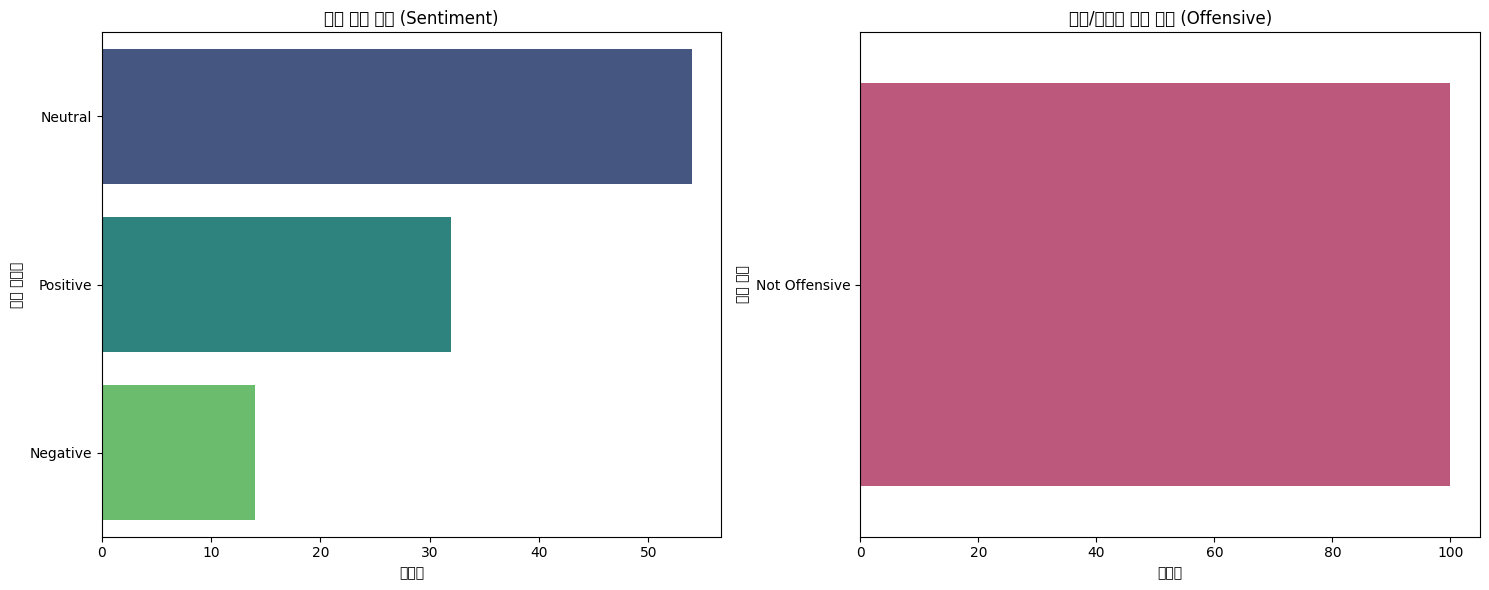

In [ ]:

print("--- 최종 결과 데이터셋 (3개 샘플) ---")
df_final = pd.DataFrame(final_dataset)

# 최종 확인을 위해 필요한 컬럼만 선택
columns_to_show = ['text', 'predicted_sentiment', 'sentiment_score', 'is_offensive', 'offensive_score']
df_final_preview = df_final[columns_to_show]

# 원문이 길면 줄여서 출력
df_final_preview['text'] = df_final_preview['text'].apply(lambda x: x[:70].replace('\n', ' ') + '...')

# 최종 결과 확인 (첫 3개 샘플)
for i in range(min(3, len(final_dataset))):
    print(f"\n--- 샘플 {i+1} ---")
    print(f"원문: {final_dataset[i]['text'][:70].replace('\n', ' ')}...")
    print(f"예측 감성: {final_dataset[i]['predicted_sentiment']} (Score: {final_dataset[i]['sentiment_score']:.3f})")
    print(f"공격성 여부: {final_dataset[i]['is_offensive']} (Score: {final_dataset[i]['offensive_score']:.3f})")

print("\n--- 시각화: 두 분류 작업 결과 분포 ---")

# 시각화: 두 분류 결과의 분포를 나란히 표시
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. 감성 분류 결과
sns.countplot(y='predicted_sentiment', data=df_final, ax=axes[0], order=df_final['predicted_sentiment'].value_counts().index, palette='viridis')
axes[0].set_title('예측 감성 분포 (Sentiment)')
axes[0].set_xlabel('빈도수')
axes[0].set_ylabel('감성 레이블')

# 2. 혐오/공격성 분류 결과
sns.countplot(y='is_offensive', data=df_final, ax=axes[1], order=df_final['is_offensive'].value_counts().index, palette='plasma')
axes[1].set_title('혐오/공격성 여부 분포 (Offensive)')
axes[1].set_xlabel('빈도수')
axes[1].set_ylabel('분류 결과')

plt.tight_layout()
print("두 분류 작업의 최종 결과 시각화 준비 완료. ")